Ignacio Agustin Costarelli - a2213

Actividad 1 — Interpretabilidad de modelos

In [1]:
from pathlib import Path
import sys
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

SEED = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)


1. Carga y EDA breve

Para predecir salary_in_usd, el salario anual en USD, empiezo por revisar las columnas del dataset y qué información aporta cada una sobre los registros salariales:

- work_year: año del registro.
- experience_level: nivel de experiencia: EN (inicial), MI (intermedio), SE (senior) y EX (ejecutivo).
- employment_type: tipo de empleo: FT, PT, CT y FL.
- job_title: puesto de trabajo.
- salary: monto del salario en la moneda original.
- salary_currency: moneda original del salario.
- salary_in_usd: monto del salario expresado en USD.
- employee_residence: país de residencia de la persona empleada.
- company_location: país donde se ubica la empresa.
- company_size: tamaño de la empresa: S, M y L.
- remote_ratio: modalidad de trabajo, con valores 0, 50 y 100. Aunque es numérica, la trato como categórica porque representa tres modalidades de trabajo.

Mantengo el año como variable numérica.

Espero que incluir salary como predictora introduzca fuga de información al predecir salary_in_usd, porque es el mismo salario expresado en su moneda original. Esta expectativa surge directamente del significado de las columnas, si quiero estimar un salario desconocido, usar salary supone darle al modelo ese monto de antemano, aunque esté en otra moneda.

In [2]:
df_raw = pd.read_csv("ds_salaries.csv")
print(f"Filas: {len(df_raw):,}; columnas: {df_raw.shape[1]}")
display(df_raw.head())
df_raw.info()
display(pd.DataFrame({"tipo": df_raw.dtypes.astype(str),
                      "nulos": df_raw.isna().sum(), "valores únicos": df_raw.nunique()}))
filas_repetidas = df_raw.duplicated().sum()
porcentaje_repetidas = filas_repetidas / len(df_raw) * 100
print(f"Filas que coinciden con una anterior: {filas_repetidas:,} ({porcentaje_repetidas:.1f}%)")

Filas: 3,755; columnas: 11


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


,tipo,nulos,valores únicos
work_year,int64,0,4
experience_level,object,0,4
employment_type,object,0,4
job_title,object,0,93
salary,int64,0,815
salary_currency,object,0,20
salary_in_usd,int64,0,1035
employee_residence,object,0,78
remote_ratio,int64,0,3
company_location,object,0,72


Filas que coinciden con una anterior: 1,171 (31.2%)


Calidad de los datos

Al revisar el dataset encontré 1.171 filas que coinciden en todos sus campos con alguna fila anterior, lo que representa el 31,2% de los 3.755 registros. Decidí conservarlas para no asumir que corresponden a la misma persona, porque no tengo un identificador de persona u oferta que me permita distinguir una carga duplicada de distintas observaciones con las mismas características. Dado que eliminarlas supondría descartar casi un tercio del dataset, prefiero mantener la distribución original antes que quitar registros que podrían ser válidos. Ese porcentaje muestra el alcance de la decisión, pero no demuestra por sí solo el origen de las coincidencias.

Conservo entonces las 3.755 filas y dejo esta duda como una limitación del análisis, al separar los datos pueden quedar registros idénticos en entrenamiento y prueba, de modo que no puedo garantizar la independencia entre observaciones y las métricas podrían ser optimistas si efectivamente hubiera registros duplicados de una misma persona u oferta.

En cuanto a los salarios extremos, también decidí conservarlos porque un monto alto no es suficiente para considerar que el registro está mal y me interesa observar cómo responde el modelo en esos casos.

Trabajo con las 3,755 filas originales, sin eliminar las coincidencias.


,salary,salary_in_usd,work_year,remote_ratio
count,3755.00,3755.00,3755.00,3755.00
mean,190695.57,137570.39,2022.37,46.27
std,671676.50,63055.63,0.69,48.59
min,6000.00,5132.00,2020.00,0.00
25%,100000.00,95000.00,2022.00,0.00
50%,138000.00,135000.00,2022.00,0.00
75%,180000.00,175000.00,2023.00,100.00
max,30400000.00,450000.00,2023.00,100.00


,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,3755,3755,3755,3755,3755,3755,3755
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,2516,3718,1040,3224,3004,3040,3153


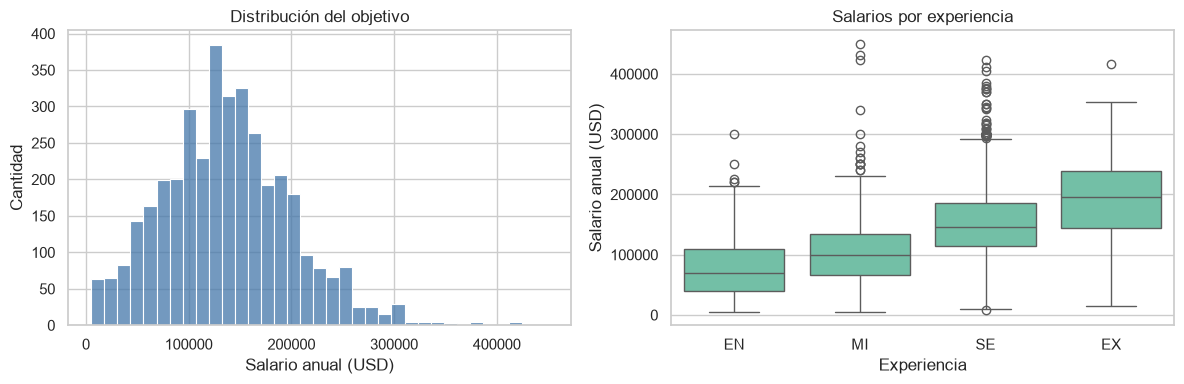

,count,mean,median
experience_level,,,
EN,320,78546.28,70000.0
EX,114,194930.93,196000.0
MI,805,104525.94,100000.0
SE,2516,153051.07,146000.0


In [3]:
df = df_raw.copy()
assert df.notna().all().all(), "Revisar faltantes antes de continuar."
assert (df[["salary", "salary_in_usd"]] > 0).all().all()
assert set(df.remote_ratio).issubset({0, 50, 100})
print(f"Trabajo con las {len(df):,} filas originales, sin eliminar las coincidencias.")
display(df[["salary", "salary_in_usd", "work_year", "remote_ratio"]].describe().round(2))
categoricas = df.select_dtypes(include=["object", "string"]).columns.tolist()
display(df[categoricas].describe())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.salary_in_usd, bins=35, ax=axes[0], color="#4477AA")
axes[0].set(xlabel="Salario anual (USD)", ylabel="Cantidad", title="Distribución del objetivo")
sns.boxplot(data=df, x="experience_level", y="salary_in_usd",
            order=["EN", "MI", "SE", "EX"], ax=axes[1], color="#66CCAA")
axes[1].set(xlabel="Experiencia", ylabel="Salario anual (USD)", title="Salarios por experiencia")
plt.tight_layout()
plt.show()
display(df.groupby("experience_level").salary_in_usd.agg(["count", "mean", "median"]).round(2))

En la distribución observo una mediana de USD 135.000 y una media de USD 137.570, junto con una cola hacia los salarios altos que llega a un máximo de USD 450.000. También veo diferencias entre los niveles de experiencia, aunque las interpreto como asociaciones porque el gráfico no me permite separar la influencia del país, el puesto u otras características. Con esta revisión busco conocer los datos y tener una referencia para interpretar el modelo, sin ajustar hiperparámetros.

2. Entrenamiento inicial

Para el primer modelo uso todas las columnas salvo salary_in_usd como predictoras, incluida salary, tal como pide la consigna, y reservo el 20% de los registros para prueba con la semilla fijada en 42. Codifico las variables categóricas con one-hot dentro de un pipeline que ajusto únicamente con los datos de entrenamiento y uso Random Forest con sus hiperparámetros por defecto, salvo random_state, que fijo para poder repetir el resultado. Como trabajo con árboles, no necesito escalar las variables.

Evalúo el desempeño con R², MAE y RMSE, y lo comparo con un modelo que siempre predice la media del entrenamiento. MAE y RMSE me permiten leer el error en USD, con una penalización mayor de los errores grandes en el caso de RMSE. Interpreto este primer resultado teniendo presente la fuga anticipada: incluir salary permite aprovechar un salario ya conocido. La comparación posterior al retirarla me permitirá medir cuánto del desempeño depende de esa información.

Train: 3004; test: 751


,modelo,conjunto,R2,MAE_USD,RMSE_USD
0,Referencia: media,test,-0.001,48917.756,62878.335
1,Original,train,0.994,677.757,4907.004
2,Original,test,0.983,1300.910,8174.219


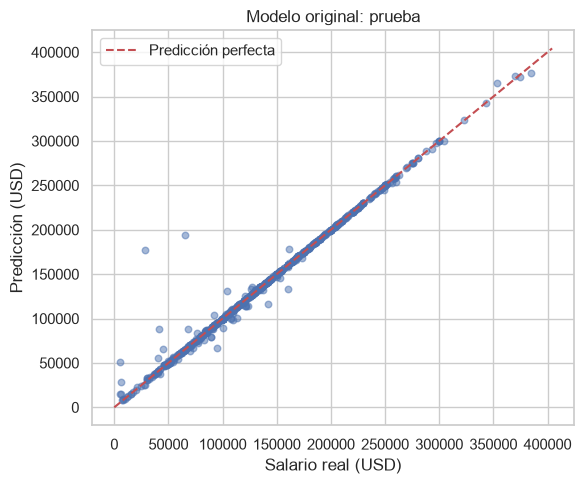

In [4]:
TARGET = "salary_in_usd"
X = df.drop(columns=TARGET)
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

def construir_modelo(datos):
    cats = datos.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    cats.append("remote_ratio")
    nums = [c for c in datos.columns if c not in cats]
    prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cats),
        ("num", "passthrough", nums)
    ])
    return Pipeline([("preprocessor", prep),
                     ("model", RandomForestRegressor(random_state=SEED))])

def metricas(nombre, reales, predicciones, conjunto="test"):
    return {"modelo": nombre, "conjunto": conjunto,
            "R2": r2_score(reales, predicciones),
            "MAE_USD": mean_absolute_error(reales, predicciones),
            "RMSE_USD": np.sqrt(mean_squared_error(reales, predicciones))}

modelo_original = construir_modelo(X_train)
modelo_original.fit(X_train, y_train)
pred_original = modelo_original.predict(X_test)
baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
resultados = [metricas("Referencia: media", y_test, baseline.predict(X_test)),
              metricas("Original", y_train, modelo_original.predict(X_train), "train"),
              metricas("Original", y_test, pred_original)]
print(f"Train: {len(X_train)}; test: {len(X_test)}")
display(pd.DataFrame(resultados).round(3))
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, pred_original, alpha=0.5, s=22)
limites = [0, max(y_test.max(), pred_original.max()) * 1.05]
ax.plot(limites, limites, "r--", label="Predicción perfecta")
ax.set(xlabel="Salario real (USD)", ylabel="Predicción (USD)", title="Modelo original: prueba")
ax.legend()
plt.tight_layout()
plt.show()

3. Importancia global con PFI

Para calcular la PFI, permuto una columna original del conjunto de prueba por vez y mido cuánto cae el R² sin volver a entrenar el modelo, de modo que una caída mayor indica una mayor dependencia de esa variable. Repito el procedimiento 10 veces por columna y muestro la media junto con el desvío estándar de las permutaciones, que no interpreto como un intervalo de confianza. La caída puede superar 1 si el R² obtenido después de permutar queda negativo.

Al leer las importancias, tengo en cuenta que no me indican si una variable aumenta o reduce el salario y que dos variables pueden sustituirse si comparten información. También considero que la permutación puede generar combinaciones poco realistas, por lo que necesito relacionar estos resultados con el contenido de las variables antes de sacar conclusiones.

,variable,importancia,desvio
4,salary,1.9145,0.0807
5,salary_currency,0.4257,0.0324
6,employee_residence,0.0016,0.0002
8,company_location,0.0011,0.0002
0,work_year,0.0003,0.0000
9,company_size,0.0002,0.0003
7,remote_ratio,0.0001,0.0006
2,employment_type,0.0000,0.0000
3,job_title,0.0000,0.0002
1,experience_level,-0.0002,0.0002


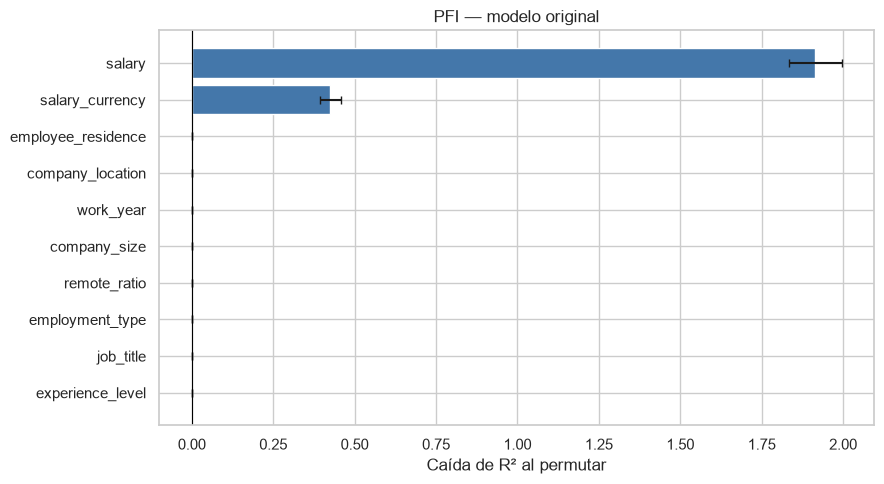

In [5]:
def calcular_pfi(modelo, datos, objetivo):
    res = permutation_importance(modelo, datos, objetivo, scoring="r2",
                                 n_repeats=10, random_state=SEED)
    return pd.DataFrame({"variable": datos.columns, "importancia": res.importances_mean,
                         "desvio": res.importances_std}).sort_values("importancia", ascending=False)

def graficar_pfi(tabla, titulo):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(tabla.variable, tabla.importancia, xerr=tabla.desvio, color="#4477AA", capsize=3)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(xlabel="Caída de R² al permutar", title=titulo)
    plt.tight_layout()
    plt.show()

pfi_original = calcular_pfi(modelo_original, X_test, y_test)
display(pfi_original.round(4))
graficar_pfi(pfi_original, "PFI — modelo original")

Como esperaba por la relación entre las columnas, salary domina la PFI con una importancia de 1,914, seguida por salary_currency con 0,426, mientras que las demás variables tienen importancias muy pequeñas en este modelo. Este resultado cuantifica la dependencia del monto original y de su moneda, en línea con la fuga anticipada al describir los datos.

4. Explicaciones locales con SHAP

Elijo la predicción más baja y la más alta del conjunto de prueba para observar cómo llega el modelo a dos resultados distintos, teniendo en cuenta que son casos extremos y no una muestra representativa de su desempeño. Para explicarlos uso TreeExplainer con tree_path_dependent, cuyo valor base toma como referencia la distribución de entrenamiento registrada en los árboles.

Como el modelo recibe columnas codificadas con one-hot, sumo sus contribuciones para poder leer la explicación en términos de las variables originales, incluidas las categorías ausentes, y compruebo que el valor base más esas contribuciones coincida con la predicción. Estoy agrupando valores SHAP ya calculados, sin recalcular Shapley con cada variable original como un único jugador. A partir de esa referencia, interpreto los valores positivos como aumentos de la predicción y los negativos como reducciones.

In [6]:
posiciones = [int(np.argmin(pred_original)), int(np.argmax(pred_original))]
casos = X_test.iloc[posiciones].copy()
resumen_casos = casos.copy()
resumen_casos["real_USD"] = y_test.iloc[posiciones]
resumen_casos["prediccion_USD"] = pred_original[posiciones]
resumen_casos["error_absoluto_USD"] = abs(resumen_casos.real_USD - resumen_casos.prediccion_USD)
display(resumen_casos)

prep = modelo_original.named_steps["preprocessor"]
arboles = modelo_original.named_steps["model"]
casos_trans = prep.transform(casos)
explainer = shap.TreeExplainer(arboles, feature_perturbation="tree_path_dependent", model_output="raw")
exp = explainer(casos_trans)

origen = []
for nombre, transformador, columnas in prep.transformers_:
    if nombre == "cat":
        for columna, categorias in zip(columnas, transformador.categories_):
            origen.extend([columna] * len(categorias))
    elif nombre == "num":
        origen.extend(columnas)
assert len(origen) == exp.values.shape[1]
shap_agrupado = np.column_stack([
    exp.values[:, np.array(origen) == columna].sum(axis=1) for columna in X_train.columns
])
bases = np.asarray(exp.base_values).reshape(-1)
np.testing.assert_allclose(bases + shap_agrupado.sum(axis=1), pred_original[posiciones], rtol=1e-6)
exp_agrupada = shap.Explanation(values=shap_agrupado, base_values=bases,
                               data=casos.to_numpy(), feature_names=X_train.columns.tolist())
print("La suma de SHAP y el valor base coincide con las dos predicciones.")

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,real_USD,prediccion_USD,error_absoluto_USD
573,2023,EN,FT,Autonomous Vehicle Technician,7000,USD,GH,0,GH,S,7000,7874.24,874.24
1288,2023,SE,FT,Data Analyst,385000,USD,US,0,US,M,385000,377020.42,7979.58


La suma de SHAP y el valor base coincide con las dos predicciones.


Predicción baja - índice 573


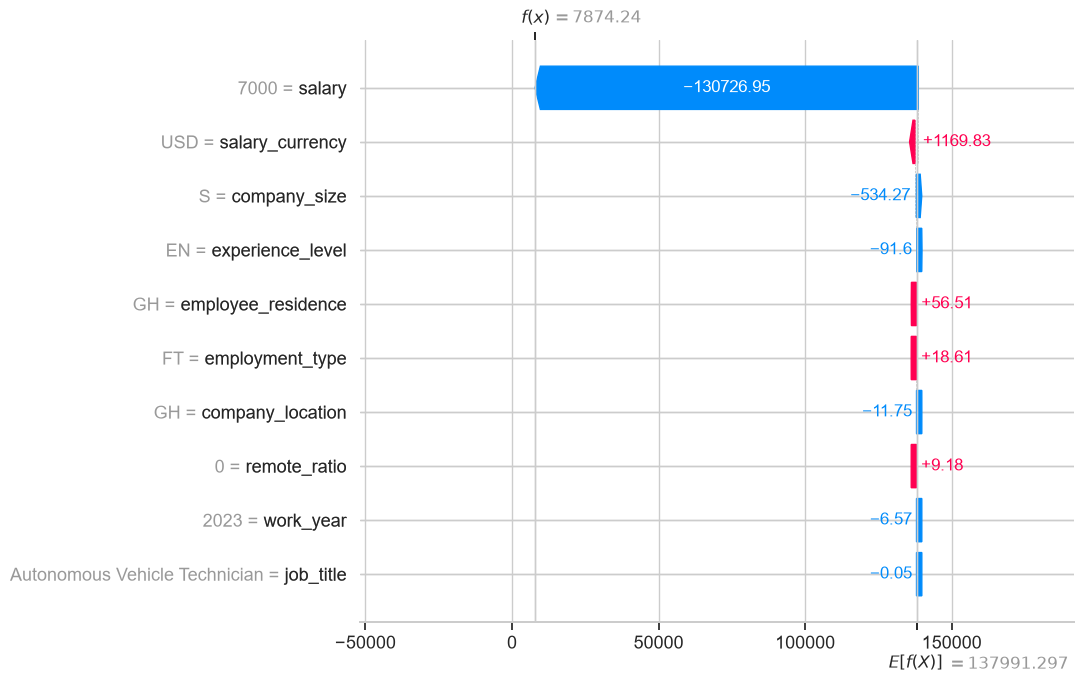

,variable,valor,SHAP_USD
4,salary,7000,-130726.945264
5,salary_currency,USD,1169.832757
9,company_size,S,-534.270291
1,experience_level,EN,-91.602106
6,employee_residence,GH,56.510726
2,employment_type,FT,18.609293
8,company_location,GH,-11.750409
7,remote_ratio,0,9.179042
0,work_year,2023,-6.572018
3,job_title,Autonomous Vehicle Technician,-0.049136


Predicción alta - índice 1288


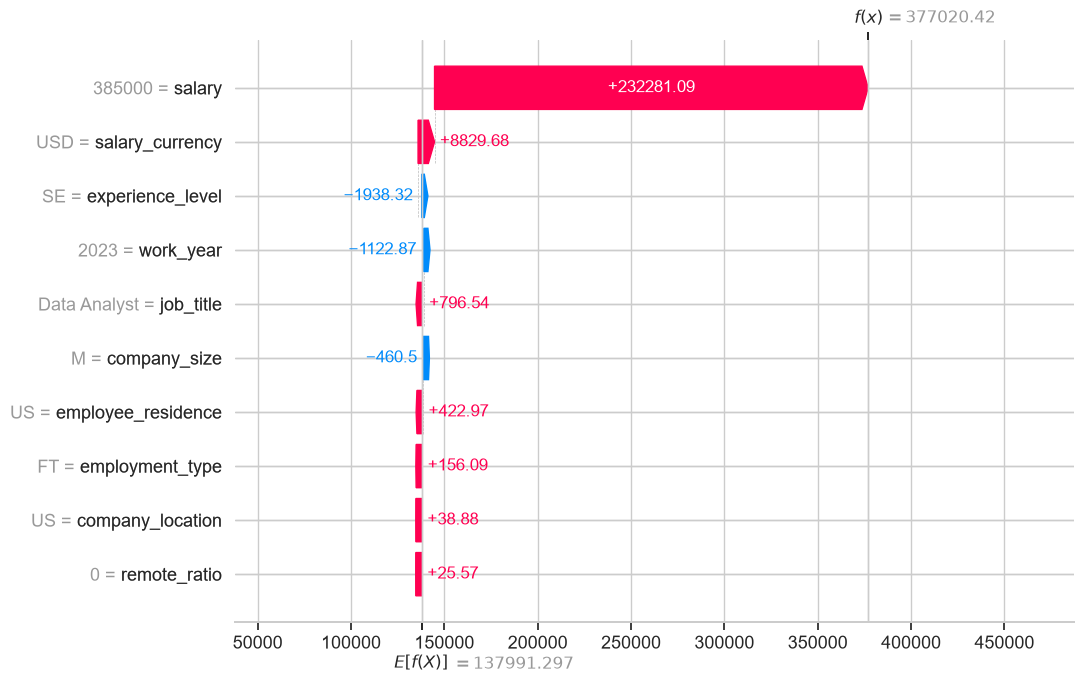

,variable,valor,SHAP_USD
4,salary,385000,232281.088278
5,salary_currency,USD,8829.682773
1,experience_level,SE,-1938.323049
0,work_year,2023,-1122.869717
3,job_title,Data Analyst,796.542648
9,company_size,M,-460.501448
6,employee_residence,US,422.967550
2,employment_type,FT,156.089634
8,company_location,US,38.880433
7,remote_ratio,0,25.565491


In [7]:
for i, etiqueta in enumerate(["Predicción baja", "Predicción alta"]):
    print(f"{etiqueta} - índice {casos.index[i]}")
    shap.plots.waterfall(exp_agrupada[i], max_display=len(X_train.columns), show=False)
    figura = plt.gcf()
    figura.set_size_inches(11, 7)

    izquierda, derecha = figura.axes[0].get_xlim()
    margen = (derecha - izquierda) * 0.37
    for eje in figura.axes:
        eje.set_xlim(izquierda - margen, derecha + margen)
    plt.tight_layout()
    plt.show()

    contrib = pd.DataFrame({
        "variable": X_train.columns,
        "valor": casos.iloc[i].to_numpy(),
        "SHAP_USD": shap_agrupado[i]
    })
    contrib = contrib.sort_values("SHAP_USD", key=abs, ascending=False)
    display(contrib)

En el caso de la predicción baja, correspondiente al registro 573, parto de un valor base de USD 137.991 y llego a una estimación de USD 7.874 frente a un salario real de USD 7.000. Al revisar las contribuciones, encuentro que esa caída se explica principalmente por salary, que reduce la estimación en USD 130.727, mientras que salary_currency la aumenta en USD 1.170 y company_size la reduce en USD 534.

Para la predicción alta, correspondiente al registro 1288, obtengo USD 377.020 frente a un salario real de USD 385.000, partiendo del mismo valor base. En este caso veo que salary aumenta la estimación en USD 232.281 y salary_currency en USD 8.830, mientras que la tercera contribución por magnitud corresponde a experience_level, que la reduce en USD 1.938.

Las dos explicaciones locales también reflejan la dependencia esperada del monto original y de su moneda, al igual que en la PFI global, salary aparece en primer lugar y salary_currency en segundo. En ambos registros la moneda es USD y su contribución es positiva, aunque con distinta magnitud, un comportamiento compatible con que ayude a interpretar el monto para convertirlo a USD. Esto no me permite afirmar que elegir esa moneda cause un salario mayor, ya que las contribuciones describen al modelo y no efectos causales.

Aunque aquí los rankings coinciden, no espero que ocurra en todos los casos. Con PFI evalúo una caída de desempeño en el conjunto, mientras que con SHAP explico cómo se compone una predicción individual.

5. Auditoría del modelo

Para documentar en los datos la relación anticipada entre las columnas, comparo salary con salary_in_usd en los registros cuya moneda es USD y calculo el cociente entre ambos montos por moneda y año. Esta revisión permite comprobar cómo se refleja la conversión del salario en el dataset y qué proporción de los registros tiene ambos montos iguales. La fuga se identifica por el significado de la variable y su disponibilidad al predecir, PFI y SHAP muestran cuánto la aprovecha el modelo, pero una importancia alta por sí sola no demuestra leakage.

In [8]:
es_usd = df.salary_currency.eq("USD")
igualdad_usd = np.isclose(df.loc[es_usd, "salary"], df.loc[es_usd, TARGET]).mean()
auditoria_conversion = df.assign(factor=df[TARGET] / df.salary)
display(auditoria_conversion.groupby(["salary_currency", "work_year"]).factor
        .agg(["count", "median", "min", "max"]).round(5))
print(f"USD: {es_usd.sum()} perfiles ({es_usd.mean():.1%}); igualdad salary = target: {igualdad_usd:.1%}")
print(f"Residencia y país de la empresa iguales: {df.employee_residence.eq(df.company_location).mean():.1%}")
display(df.company_location.value_counts().head(8).rename("cantidad"))
categorias_nuevas = {}
for columna in categoricas + ["remote_ratio"]:
    nuevas = set(X_test[columna]) - set(X_train[columna])
    categorias_nuevas[columna] = len(nuevas)

display(pd.Series(categorias_nuevas, name="Categorías de test ausentes en train"))

count   median      min      max
salary_currency work_year                                  
AUD             2021           2  0.75050  0.75050  0.75050
                2022           6  0.69309  0.69308  0.69309
                2023           1  0.68318  0.68318  0.68318
BRL             2021           2  0.18536  0.18536  0.18536
                2022           3  0.19352  0.19352  0.19352
                2023           1  0.19252  0.19252  0.19252
CAD             2020           1  0.74589  0.74589  0.74589
                2021          10  0.79762  0.79762  0.79763
                2022          11  0.76815  0.76814  0.76815
                2023           3  0.73933  0.73933  0.73933
CHF             2022           3  1.04697  1.04696  1.04697
                2023           1  1.08119  1.08119  1.08119
CLP             2021           1  0.00132  0.00132  0.00132
CZK             2022           1  0.04277  0.04277  0.04277
DKK             2020           1  0.15299  0.15299  0.15299
                2021           2  0.15894  0.15894  0.15894
EUR             2020          24  1.14046  1.14043  1.14047
                2021          44  1.18205  1.18196  1.18206
                2022         115  1.05066  1.05065  1.05067
                2023          53  1.07308  1.07305  1.07309
GBP             2020           3  1.28264  1.28263  1.28264
                2021          13  1.37546  1.37545  1.37547
                2022          83  1.23133  1.23131  1.23133
                2023          62  1.21523  1.21521  1.21523
HKD             2023           1  0.12757  0.12757  0.12757
HUF             2020           1  0.00325  0.00325  0.00325
                2021           1  0.00330  0.00330  0.00330
                2022           1  0.00268  0.00268  0.00268
ILS             2023           1  0.28256  0.28256  0.28256
INR             2020           6  0.01349  0.01349  0.01349
                2021          23  0.01352  0.01352  0.01352
                2022          20  0.01272  0.01272  0.01272
                2023          11  0.01216  0.01216  0.01216
JPY             2020           1  0.00937  0.00937  0.00937
                2021           2  0.00910  0.00910  0.00910
MXN             2020           1  0.04654  0.04654  0.04654
PLN             2021           2  0.25887  0.25887  0.25887
                2022           2  0.22406  0.22406  0.22407
                2023           1  0.22794  0.22794  0.22794
SGD             2021           3  0.74412  0.74411  0.74412
                2022           1  0.72508  0.72508  0.72508
                2023           2  0.75020  0.75020  0.75020
THB             2023           2  0.02945  0.02945  0.02945
TRY             2021           3  0.11206  0.11206  0.11206
USD             2020          38  1.00000  1.00000  1.00000
                2021         122  1.00000  1.00000  1.00000
                2022        1418  1.00000  1.00000  1.00000
                2023        1646  1.00000  1.00000  1.00000

USD: 3224 perfiles (85.9%); igualdad salary = target: 100.0%
Residencia y país de la empresa iguales: 97.4%


company_location
US    3040
GB     172
CA      87
ES      77
IN      58
DE      56
FR      34
BR      15
Name: cantidad, dtype: int64

experience_level      0
employment_type       0
job_title             8
salary_currency       1
employee_residence    4
company_location      4
company_size          0
remote_ratio          0
Name: Categorías de test ausentes en train, dtype: int64

Hallazgos y decisiones

La auditoría confirma la relación que esperaba por la definición de salary y salary_in_usd, ambos montos coinciden en todos los perfiles cuya moneda es USD, que representan el 85,9% de los datos, y su cociente es casi constante al agrupar por moneda y año. Junto con la PFI de 1,914 y el predominio de salary en las dos explicaciones SHAP, estos resultados muestran que el modelo aprovecha esa información para convertir, en buena parte, un salario ya conocido. Como anticipé al inicio, retiro salary y vuelvo a entrenar con la misma partición para medir el desempeño sin conocer el monto original.

También encuentro que employee_residence y company_location coinciden en el 97,4% de los perfiles, algo que me resulta razonable si la mayoría de las personas reside en el país de la empresa. Como ambas variables pueden aportar información sobre el mismo mercado laboral y sustituirse entre sí, voy a calcular su PFI conjunta antes de concluir que alguna no aporta información.

Respecto de las 1.171 filas que coinciden con alguna anterior, decidí no eliminarlas para no asumir que representan a la misma persona. Quitarlas habría descartado el 31,2% del dataset sin evidencia suficiente, por lo que mantengo las 3.755 observaciones y su peso original en el análisis. Para distinguir publicaciones duplicadas de personas con el mismo perfil y salario necesitaría confirmar con el proveedor qué representa cada registro, una duda que no puedo resolver mediante PFI o SHAP y que me impide garantizar la independencia entre entrenamiento y prueba.

Por otra parte, observo una concentración de registros en Estados Unidos y categorías del test que no aparecen en entrenamiento, lo que me lleva a revisar los errores por experiencia y país junto con la cantidad de casos de cada grupo. Las dos explicaciones SHAP me permiten analizar extremos, pero no evaluar toda esa diversidad; para usar el modelo en otros años o grupos poco representados, necesitaría más datos y una validación temporal.

En el reentrenamiento mantengo salary_currency porque, sin conocer el monto, la moneda no revela por sí sola el salario y conservarla me permite observar el efecto de quitar únicamente salary. Si tampoco dispusiera de la moneda al momento de predecir, tendría que retirarla y evaluar de nuevo.

6. Reentrenamiento sin salary

Para comparar el efecto de retirar salary, vuelvo a entrenar con los mismos registros, la misma codificación y los mismos hiperparámetros, y después reviso las métricas y la PFI. Como ya consulté el conjunto de prueba durante la auditoría, tomo esta comparación como parte del análisis y necesitaría otro conjunto para hacer una evaluación final independiente antes de usar el modelo.

,modelo,conjunto,R2,MAE_USD,RMSE_USD
0,Referencia: media,test,-0.001,48917.756,62878.335
1,Original,train,0.994,677.757,4907.004
2,Original,test,0.983,1300.910,8174.219
3,Sin salary,train,0.592,29402.401,40292.809
4,Sin salary,test,0.398,36498.080,48740.917


,variable,importancia,desvio
5,employee_residence,0.2816,0.0214
1,experience_level,0.1846,0.0202
3,job_title,0.1538,0.0225
4,salary_currency,0.0839,0.0069
6,remote_ratio,0.0243,0.0079
0,work_year,0.0235,0.0087
8,company_size,0.0096,0.0050
7,company_location,0.0036,0.0022
2,employment_type,-0.0001,0.0003


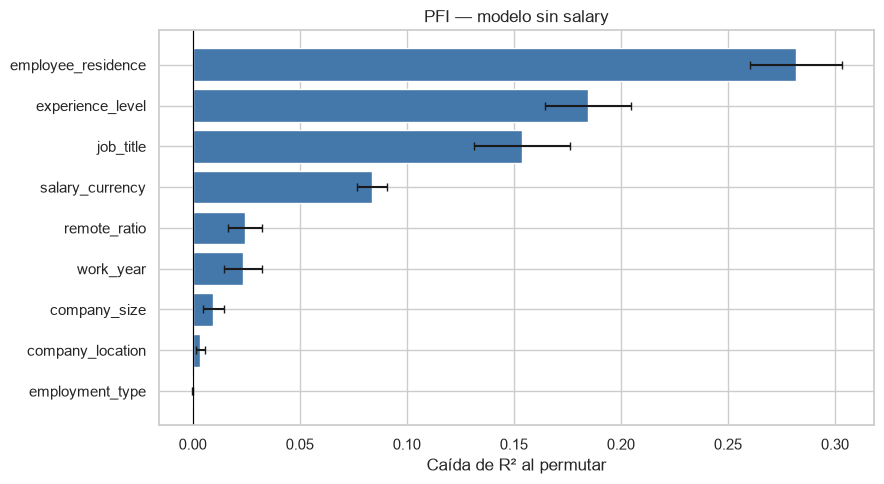

,original,sin_salary
variable,,
company_location,0.001054,0.003582
company_size,0.000161,0.009611
employee_residence,0.001581,0.281637
employment_type,0.000040,-0.000128
experience_level,-0.000169,0.184581
job_title,0.000035,0.153840
remote_ratio,0.000068,0.024266
salary,1.914474,NaN
salary_currency,0.425691,0.083911


In [9]:
X_train_limpio = X_train.drop(columns="salary")
X_test_limpio = X_test.drop(columns="salary")
modelo_limpio = construir_modelo(X_train_limpio)
modelo_limpio.fit(X_train_limpio, y_train)
pred_limpio = modelo_limpio.predict(X_test_limpio)
resultados_limpio = [
    metricas("Sin salary", y_train, modelo_limpio.predict(X_train_limpio), "train"),
    metricas("Sin salary", y_test, pred_limpio)
]
comparacion = pd.DataFrame(resultados + resultados_limpio)
display(comparacion.round(3))
pfi_limpio = calcular_pfi(modelo_limpio, X_test_limpio, y_test)
display(pfi_limpio.round(4))
graficar_pfi(pfi_limpio, "PFI — modelo sin salary")
comparacion_pfi = pd.DataFrame({
    "original": pfi_original.set_index("variable")["importancia"],
    "sin_salary": pfi_limpio.set_index("variable")["importancia"]
})
display(comparacion_pfi)

In [ ]:
rng = np.random.default_rng(SEED)
score_limpio = r2_score(y_test, pred_limpio)
caidas_paises = []
columnas = ["employee_residence", "company_location"]
for _ in range(10):
    permutado = X_test_limpio.copy()
    orden = rng.permutation(len(permutado))
    permutado[columnas] = X_test_limpio.iloc[orden][columnas].to_numpy()
    caidas_paises.append(score_limpio - r2_score(y_test, modelo_limpio.predict(permutado)))
print(f"PFI conjunta de países: {np.mean(caidas_paises):.4f} ± {np.std(caidas_paises):.4f}")
print("Esta PFI conjunta no equivale a sumar las importancias individuales.")

errores = X_test_limpio.assign(real_USD=y_test, pred_USD=pred_limpio,
                              error_abs_USD=np.abs(y_test - pred_limpio))
display(errores.groupby("experience_level").agg(n=("real_USD", "size"),
        salario_medio=("real_USD", "mean"), MAE_USD=("error_abs_USD", "mean")).round(2))
display(errores.groupby("company_location").agg(n=("real_USD", "size"),
        MAE_USD=("error_abs_USD", "mean")).sort_values("n", ascending=False).head(10).round(2))
display(pd.DataFrame({"real_USD": y_test.iloc[posiciones],
                      "original_USD": pred_original[posiciones], "sin_salary_USD": pred_limpio[posiciones]}).round(2))

PFI conjunta de países: 0.2991 ± 0.0192
Esta PFI conjunta no equivale a sumar las importancias individuales.


,n,salario_medio,MAE_USD
experience_level,,,
EN,67,72839.85,26091.19
EX,23,177765.09,53098.03
MI,157,108076.92,29018.84
SE,504,150634.28,39453.84


,n,MAE_USD
company_location,,
US,596,39113.84
GB,36,22402.55
ES,20,8216.23
CA,19,43080.27
IN,13,13697.14
DE,12,24666.69
FR,7,27365.47
AU,5,37293.94
PT,3,32474.93


,real_USD,original_USD,sin_salary_USD
573,7000,7874.24,19554.75
1288,385000,377020.42,130621.21


Comparación de los resultados

Al quitar salary, observo que la PFI de salary_currency baja de 0,426 a 0,084, lo que coincide con la idea de que antes ayudaba a interpretar el monto original. En su lugar, las mayores importancias corresponden a residencia (0,282), experiencia (0,185) y puesto (0,154), un resultado que me parece razonable porque estas variables describen el mercado laboral y las responsabilidades del empleo, aunque no puedo interpretarlas como causas del salario.

La PFI conjunta de los países es 0,299, frente a 0,282 para residencia y 0,004 para país de la empresa, por lo que entiendo que el modelo aprovecha esa información compartida principalmente a través de la residencia. Esto me lleva a ser cuidadoso con la PFI baja de company_location, ya que no alcanza para afirmar que el país de la empresa sea irrelevante.

En este modelo, company_location y company_size tienen importancias pequeñas y positivas, de aproximadamente 0,004 y 0,010. La única PFI negativa corresponde a employment_type y está muy cerca de cero (-0,0001), con un desvío de 0,0003 entre permutaciones, por lo que no veo una contribución clara de esa variable en esta evaluación. No la quitaría únicamente por ese resultado ni lo interpretaría como una reducción del salario.

En cuanto al desempeño, obtengo un R² de 0,592 en entrenamiento y de 0,398 en prueba, una diferencia que me hace pensar en sobreajuste y en características que el modelo no está capturando. Aunque el MAE baja de los USD 48.918 de la referencia a USD 36.498, el error sigue siendo alto. En los casos que expliqué con SHAP, las nuevas predicciones son aproximadamente USD 19.555 y USD 130.621, frente a salarios reales de USD 7.000 y USD 385.000; la diferencia resulta especialmente grande en el segundo caso. La pérdida de precisión respecto del modelo inicial era esperable al retirar salary, estos resultados muestran la magnitud de esa dependencia. Necesitaría revisar esos perfiles y la información disponible antes de confiar en las nuevas estimaciones.

Para interpretar las diferencias entre grupos, también tengo en cuenta el tamaño de cada uno. Por ejemplo, EX tiene 23 casos de prueba y un MAE de USD 53.098. Necesitaría más observaciones y una medida de incertidumbre para evaluar esas diferencias, porque estos errores por sí solos no me permiten concluir que exista discriminación o equidad.

Como mantuve las filas coincidentes, tampoco tomo estos resultados como garantía de desempeño sobre personas u ofertas independientes. Sin identificar el origen de esas coincidencias no puedo saber cuánto podrían favorecer las métricas de la partición aleatoria.

7. Conclusiones

Con todas las variables obtuve un R² de 0,983, un MAE de USD 1.301 y un RMSE de USD 8.174 en prueba, mientras que después de quitar salary esos valores pasaron a 0,398, USD 36.498 y USD 48.741, respectivamente. Esta caída confirma el comportamiento esperado desde la lectura de las columnas, el modelo inicial disponía del mismo salario en su moneda original. El aporte de PFI, SHAP y el reentrenamiento fue mostrar y cuantificar cuánto dependía de esa información, que no tendría al estimar un salario desconocido.

Después de corregir esa fuga encuentro un comportamiento más razonable, apoyado en residencia, experiencia y puesto, aunque los errores siguen siendo altos y la diferencia entre entrenamiento y prueba limita la confianza que puedo tener en las predicciones. Antes de usar el modelo, confirmaría la procedencia de los registros y qué variables voy a conocer al predecir, además de evaluarlo con datos de otro período, ya que este análisis no me permite asegurar independencia entre personas, buen desempeño en años futuros ni equidad entre grupos.

En todo el análisis conservé las 3.755 filas, incluidas las 1.171 coincidencias adicionales que representan el 31,2% del dataset, para no asumir que corresponden a una misma persona ni descartar observaciones potencialmente válidas. Mantengo esta decisión junto con la limitación de no poder verificar la independencia de los registros.